# Protocolo walk-forward común para modelos PEMS-PINN de NOx y CO — R1

**Propósito:** construir y congelar una única definición anual, expansiva y
prospectiva para los modelos PEMS-PINN posteriores de NOx y CO.

**Alcance:** `WF01`–`WF03` constituyen desarrollo y selección con 2011–2014;
`WF04` queda reservado para la evaluación FINAL sobre 2015. El protocolo no
entrena modelos, no selecciona hiperparámetros y no materializa valores de CO,
NOX ni variables operativas de 2015.

**Entradas:** `data/raw/gt_2011.csv` a `gt_2015.csv`. Los valores operativos se
cargan únicamente para 2011–2014; de 2015 se comprueba solo existencia y esquema.

**Salidas:** asignación anual, manifiestos de folds, contrato de consumidores,
política común de campaña, controles y artefactos FROZEN en
`models/wf/work_pinn_wf_protocol/`.

**Entorno previsto:** Google Colab, con la raíz
`/content/drive/MyDrive/Turbine_Emissions_PINN`.

**Estado:** protocolo R1. Los artefactos adquieren estado `FROZEN` únicamente
después de superar todas las puertas de integridad de `SEC-06`.

## Mapa del notebook

| Sección | Finalidad |
|---|---|
| SEC-01 | entorno, configuración e inicialización |
| SEC-02 | carga X-only de desarrollo y barrera estricta de 2015 |
| SEC-03 | construcción y auditoría de `WF01`–`WF04` |
| SEC-04 | contrato común para notebooks OPT y FINAL |
| SEC-05 | diagnóstico visual del diseño temporal |
| SEC-06 | comprobaciones integrales de aceptación |
| SEC-07 | persistencia, congelamiento y cierre |

## Decisiones metodológicas congeladas

| Elemento | Contrato R1 |
|---|---|
| Desarrollo | `WF01: 2011→2012`, `WF02: 2011–2012→2013`, `WF03: 2011–2013→2014` |
| Evaluación FINAL | `WF04: 2011–2014→2015` |
| Gap | `0` registros; fijo y fuera de Optuna |
| Ponderación temporal | `uniform`; fija y fuera de Optuna |
| Física NOx | `TIT_INC`: ∂NOx/∂TIT ≥ 0 |
| Física CO | `CDP_NEG`: ∂CO/∂CDP ≤ 0 |
| Protección de 2015 | sin `X_2015`, `y_2015`, métricas ni selección durante OPT |

## Trazabilidad de diseño

- El protocolo interpolativo R1 aporta la estructura de artefactos, controles,
  escritura atómica y legibilidad; su partición interpolativa no se reutiliza.
- NOx R7 aporta la línea base del splitter anual y la protección histórica de
  2015; sus búsquedas de gap y ponderación temporal quedan retiradas.
- CO R9 aporta la línea base de CO y la hipótesis `CDP_NEG`; sus modos físicos
  alternativos y `dual_alpha` quedan retirados.
- El Manual R4 gobierna etiquetas, lectura humana, reproducibilidad y gates.
- La estructura Colab fija las rutas `data/raw`, `notebooks` y `models/wf`.

**Interpretación permitida:** el diseño evalúa transferencia prospectiva anual
dentro del dominio histórico disponible. No demuestra causalidad física, no
sustituye validación regulatoria y no equivale a certificación PEMS/CEMS o RATA.


## SEC-01 — Entorno, configuración e inicialización

La ejecución parte de una única raíz editable y deriva de ella todos los
artefactos permanentes.

### C-01.01 / CFG-01 — Preparación del entorno y raíz de Drive

**Objetivo:** declarar la ruta canónica, instalar solo dependencias ausentes y
montar Drive cuando la ejecución ocurre en Colab.  
**Entradas:** runtime de Python y `PROJECT_ROOT_PATH`.  
**Salidas:** dependencias disponibles e indicador `IN_COLAB`.  
**Control:** modificar únicamente `PROJECT_ROOT_PATH` si cambia la ubicación.


In [1]:
# [C-01.01] Preparación del entorno y raíz de Drive

# --- ÚNICA RUTA EDITABLE ---
PROJECT_ROOT_PATH = "C:\\ChatGPT-Work\\Walk_Forward R8"

import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "psutil": "psutil",
}
missing_packages = [
    package
    for module, package in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

print(
    {
        "entorno": "Colab" if IN_COLAB else "local",
        "paquetes_instalados": missing_packages,
    }
)


{'entorno': 'local', 'paquetes_instalados': []}


### C-01.02 / CFG-02 — Configuración científica congelada

**Objetivo:** centralizar años, folds, barreras, variables y linaje documental.  
**Entradas:** decisiones R1 y archivos de referencia revisados.  
**Salidas:** una sola fuente de verdad para el protocolo.  
**Control:** `gap_records`, ponderación y física no se reinterpretan en notebooks
consumidores.


In [2]:
# [C-01.02] Imports y configuración científica congelada
from __future__ import annotations

import csv
import hashlib
import importlib.metadata
import json
import os
import platform
import tempfile
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from IPython.display import display
from matplotlib.patches import Patch

PROTOCOL_VERSION = "WF_PROTOCOL_R1"
PROTOCOL_FREEZE_UTC = "2026-08-17T00:00:00Z"
FEATURES = [
    "AT",
    "AP",
    "AH",
    "AFDP",
    "GTEP",
    "TIT",
    "TAT",
    "TEY",
    "CDP",
]
PROTECTED_TARGETS = ["CO", "NOX"]
EXPECTED_COLUMNS = [*FEATURES, *PROTECTED_TARGETS]
DEVELOPMENT_YEARS = [2011, 2012, 2013, 2014]
FINAL_TEST_YEAR = 2015
ALL_YEARS = [*DEVELOPMENT_YEARS, FINAL_TEST_YEAR]
EXPECTED_ROWS_BY_YEAR = {
    2011: 7_411,
    2012: 7_628,
    2013: 7_152,
    2014: 7_158,
    2015: 7_384,
}
EXPECTED_DEVELOPMENT_ROWS = sum(
    EXPECTED_ROWS_BY_YEAR[year] for year in DEVELOPMENT_YEARS
)

GAP_RECORDS = 0
TEMPORAL_WEIGHTING = "uniform"
ALLOW_2015_FEATURE_READ = False
ALLOW_2015_TARGET_READ = False

FOLD_SPECS = [
    {
        "fold": "WF01",
        "purpose": "DEVELOPMENT",
        "train_years": [2011],
        "evaluation_year": 2012,
        "evaluation_role": "VALIDATION",
    },
    {
        "fold": "WF02",
        "purpose": "DEVELOPMENT",
        "train_years": [2011, 2012],
        "evaluation_year": 2013,
        "evaluation_role": "VALIDATION",
    },
    {
        "fold": "WF03",
        "purpose": "DEVELOPMENT",
        "train_years": [2011, 2012, 2013],
        "evaluation_year": 2014,
        "evaluation_role": "VALIDATION",
    },
    {
        "fold": "WF04",
        "purpose": "FINAL_ONLY",
        "train_years": [2011, 2012, 2013, 2014],
        "evaluation_year": 2015,
        "evaluation_role": "TEST",
    },
]

REFERENCE_SOURCES = [
    {
        "source": "00_PEMS_PINN_INTERP_PROTOCOL - R1.ipynb",
        "sha256": "38299fe842f761719b070fc340d71c645269730fd2b3eee3ef00eee72daf5e28",
        "role": "Estructura, artefactos, controles y escritura atómica",
    },
    {
        "source": "04_Gold_Standard_PINN_NOX_WF04 - R7.ipynb",
        "sha256": "dfe58b9407ab5dcb708534a1347e67afaaea643d38bad2b3f1f8197bf8b26e47",
        "role": "Splitter anual NOx, antifuga y física TIT",
    },
    {
        "source": "04_Gold_Standard_PINN_CO_WF04 - R9.ipynb",
        "sha256": "ef658af8f25667ed229f9e6864fa66bd23652f4f8221a252f286fc6064612e31",
        "role": "Splitter anual CO, antifuga y física CDP",
    },
    {
        "source": "Manual Estilo Convenciones Notebooks - R4.md",
        "sha256": "6b3664fdea88ae854399e769af44aa705e0103b18c6179c1216cd9d297215224",
        "role": "Documento rector de estilo y calidad",
    },
    {
        "source": "Estructura Archivos Colab.txt",
        "sha256": "395787c2c899d9347424611e2535b51aa826ea394359cd9a99b26966001a665a",
        "role": "Rutas canónicas de Drive",
    },
]

CANONICAL_OUTPUT_RELATIVE_PATH = (
    Path("models") / "wf" / "work_pinn_wf_protocol"
)


### C-01.03 / CHK-01 — Utilidades de trazabilidad y persistencia

**Objetivo:** ofrecer serialización estable, SHA-256 y escrituras atómicas.  
**Entradas:** objetos, tablas y rutas.  
**Salidas:** JSON, CSV y texto UTF-8 reproducibles.  
**Control:** un artefacto solo reemplaza al anterior después de escribirse por
completo.


In [3]:
# [C-01.03] Utilidades de trazabilidad y persistencia

def utc_now() -> str:
    """Devuelve el instante UTC de ejecución para auditorías no congeladas."""
    return datetime.now(timezone.utc).isoformat()


def canonical_json(value) -> str:
    """Serializa un objeto con orden y separadores deterministas."""
    return json.dumps(
        value,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    )


def sha256_bytes(value: bytes) -> str:
    return hashlib.sha256(value).hexdigest()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def atomic_text(path: Path, text: str) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    descriptor, temporary_name = tempfile.mkstemp(
        prefix=path.name + ".",
        suffix=".tmp",
        dir=path.parent,
    )
    os.close(descriptor)
    temporary_path = Path(temporary_name)
    try:
        temporary_path.write_text(text, encoding="utf-8", newline="\n")
        os.replace(temporary_path, path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()


def atomic_json(path: Path, value) -> None:
    payload = json.dumps(
        value,
        ensure_ascii=False,
        sort_keys=True,
        indent=2,
        allow_nan=False,
    )
    atomic_text(path, payload + "\n")


def atomic_csv(path: Path, frame: pd.DataFrame) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    descriptor, temporary_name = tempfile.mkstemp(
        prefix=path.name + ".",
        suffix=".tmp",
        dir=path.parent,
    )
    os.close(descriptor)
    temporary_path = Path(temporary_name)
    try:
        frame.to_csv(
            temporary_path,
            index=False,
            lineterminator="\n",
            float_format="%.12g",
        )
        os.replace(temporary_path, path)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()


### C-01.04 / CHK-02 — Validación de la estructura canónica

**Objetivo:** comprobar las cinco rutas obligatorias sin búsquedas heurísticas.  
**Entradas:** `PROJECT_ROOT_PATH`.  
**Salidas:** raíz resuelta y mapa anual de archivos.  
**Control:** la existencia de 2015 se verifica sin abrir su contenido.


In [4]:
# [C-01.04] Validación de la estructura canónica

def validate_project_root(
    project_root_path: str | Path,
) -> tuple[Path, dict[int, Path]]:
    """Valida la raíz y devuelve las cinco rutas canónicas."""
    root = Path(project_root_path).expanduser().resolve()
    data_dir = root / "data" / "raw"
    data_paths = {
        year: data_dir / f"gt_{year}.csv"
        for year in ALL_YEARS
    }
    missing = [path for path in data_paths.values() if not path.is_file()]
    if missing:
        missing_text = "\n".join(f"- {path}" for path in missing)
        raise FileNotFoundError(
            "PROJECT_ROOT_PATH no contiene la estructura canónica. "
            "Corrija únicamente esa variable y vuelva a ejecutar.\n"
            f"Raíz configurada: {root}\n"
            f"CSV ausentes:\n{missing_text}"
        )
    return root, {year: path.resolve() for year, path in data_paths.items()}


### C-01.05 / ART-01 — Inicialización y huellas de desarrollo

**Objetivo:** preparar carpetas, registrar el entorno y calcular hashes solo de
los CSV 2011–2014.  
**Entradas:** raíz y rutas verificadas.  
**Salidas:** directorios, auditoría del entorno y huellas de desarrollo.  
**Control:** el contenido de `gt_2015.csv` no se lee ni se hashea.


In [5]:
# [C-01.05] Inicialización y huellas de desarrollo

def collect_development_hashes(
    root: Path,
    data_paths: dict[int, Path],
) -> pd.DataFrame:
    """Identifica únicamente los cuatro archivos autorizados para DEV."""
    rows = []
    for year in DEVELOPMENT_YEARS:
        path = data_paths[year]
        rows.append(
            {
                "year": year,
                "role": "DEVELOPMENT",
                "path": str(path.relative_to(root)),
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
        )
    return pd.DataFrame(rows).sort_values("year").reset_index(drop=True)


def initialize_protocol(
    root: Path,
    data_paths: dict[int, Path],
) -> tuple[Path, dict[str, Path], pd.DataFrame, dict, dict]:
    """Prepara las salidas y registra el entorno reproducible."""
    output_dir = root / CANONICAL_OUTPUT_RELATIVE_PATH
    paths = {
        name: output_dir / name
        for name in ("audit", "manifests", "tables", "figures", "reports")
    }
    for path in paths.values():
        path.mkdir(parents=True, exist_ok=True)

    development_hashes = collect_development_hashes(root, data_paths)
    atomic_csv(
        paths["audit"] / "WF_DATA_HASHES_BEFORE.csv",
        development_hashes,
    )

    holdout_path = data_paths[FINAL_TEST_YEAR]
    holdout_stat = {
        "path": str(holdout_path.relative_to(root)),
        "bytes": holdout_path.stat().st_size,
        "mtime_ns": holdout_path.stat().st_mtime_ns,
        "sha256": "NOT_COMPUTED_BY_PROTOCOL",
    }
    environment = {
        "protocol_version": PROTOCOL_VERSION,
        "generated_at_utc": PROTOCOL_FREEZE_UTC,
        "python": sys.version,
        "platform": platform.platform(),
        "cpu_count_logical": psutil.cpu_count(logical=True),
        "cpu_count_physical": psutil.cpu_count(logical=False),
        "ram_gib": round(psutil.virtual_memory().total / 2**30, 3),
        "packages": {
            name: importlib.metadata.version(name)
            for name in ["numpy", "pandas", "matplotlib", "psutil"]
        },
        "in_colab": IN_COLAB,
    }
    atomic_json(
        paths["audit"] / "WF_ENVIRONMENT_MANIFEST.json",
        environment,
    )
    return output_dir, paths, development_hashes, holdout_stat, environment


### C-01.06 / OUT-01 — Inicio reproducible

**Objetivo:** activar el cronómetro e informar la configuración efectiva antes
de acceder a datos.  
**Entradas:** constantes y raíz.  
**Salidas:** `PROJECT_ROOT`, `DATA_PATHS`, `OUTPUT_DIR` y resumen inicial.  
**Control:** la pantalla debe declarar explícitamente que 2015 sigue bloqueado.


In [6]:
# [C-01.06] Inicio reproducible

RUN_STARTED = time.perf_counter()
PROJECT_ROOT, DATA_PATHS = validate_project_root(PROJECT_ROOT_PATH)
(
    OUTPUT_DIR,
    PATHS,
    DATA_HASHES_BEFORE,
    HOLDOUT_STAT_BEFORE,
    ENVIRONMENT,
) = initialize_protocol(PROJECT_ROOT, DATA_PATHS)

display(
    pd.Series(
        {
            "versión": PROTOCOL_VERSION,
            "raíz del proyecto": str(PROJECT_ROOT),
            "años DEV": DEVELOPMENT_YEARS,
            "año TEST": FINAL_TEST_YEAR,
            "gap (registros)": GAP_RECORDS,
            "ponderación temporal": TEMPORAL_WEIGHTING,
            "lectura X de 2015": ALLOW_2015_FEATURE_READ,
            "lectura y de 2015": ALLOW_2015_TARGET_READ,
        },
        name="valor",
    ).to_frame()
)


,valor
versión,WF_PROTOCOL_R1
raíz del proyecto,C:\ChatGPT-Work\Walk_Forward R8
años DEV,"[2011, 2012, 2013, 2014]"
año TEST,2015
gap (registros),0
ponderación temporal,uniform
lectura X de 2015,False
lectura y de 2015,False


## SEC-02 — Carga X-only y barrera estricta de 2015

Los encabezados de los cinco CSV se verifican para asegurar un esquema común.
Solo 2011–2014 materializan las nueve variables operativas; CO y NOX no se
cargan en ningún año, y 2015 permanece en `HEADER_ONLY`.

### C-02.01 / CHK-03 — Inspección exclusiva de encabezados

**Objetivo:** verificar nombres y orden sin materializar filas.  
**Entradas:** cinco rutas anuales.  
**Salidas:** encabezados validados.  
**Control:** el esquema debe ser exactamente `FEATURES + [CO, NOX]`.


In [7]:
# [C-02.01] Inspección exclusiva de encabezados

def read_header_only(path: Path) -> list[str]:
    """Lee únicamente la primera fila del CSV."""
    with path.open("r", encoding="utf-8-sig", newline="") as handle:
        return next(csv.reader(handle))


def validate_headers(data_paths: dict[int, Path]) -> dict[int, list[str]]:
    """Comprueba que los cinco archivos compartan el esquema canónico."""
    headers = {}
    for year in ALL_YEARS:
        header = read_header_only(data_paths[year])
        if header != EXPECTED_COLUMNS:
            raise ValueError(
                f"Esquema inesperado en {year}. "
                f"Esperado={EXPECTED_COLUMNS}; observado={header}"
            )
        headers[year] = header
    return headers


### C-02.02 / ALG-01 / CHK-04 — Preflight X-only de desarrollo

**Finalidad:** materializar X de 2011–2014, validar finitud y crear identificadores
reproducibles sin cargar objetivos.

**Lógica humana:**

1. validar los cinco encabezados;
2. cargar `FEATURES` mediante `usecols` solo para años DEV;
3. comprobar conteos y finitud;
4. crear `global_row_id`, `row_in_year` y `global_position`;
5. registrar 2015 como `HEADER_ONLY`.

**Salidas:** datos X-only, tabla preflight y auditorías de acceso.  
**Acción ante fallo:** detener antes de construir folds.


In [8]:
# [C-02.02] Preflight X-only de desarrollo

def preflight_and_load_development_x(
    root: Path,
    data_paths: dict[int, Path],
    paths: dict[str, Path],
) -> tuple[pd.DataFrame, pd.DataFrame, dict, dict, dict[int, list[str]]]:
    """Carga X de DEV y mantiene 2015 sin valores materializados."""
    headers = validate_headers(data_paths)
    frames = []
    preflight_rows = []
    global_position = 0

    for year in DEVELOPMENT_YEARS:
        path = data_paths[year]
        frame = pd.read_csv(
            path,
            usecols=FEATURES,
            dtype={feature: "float64" for feature in FEATURES},
        )
        frame = frame[FEATURES]
        expected_rows = EXPECTED_ROWS_BY_YEAR[year]
        if len(frame) != expected_rows:
            raise ValueError(
                f"Conteo inesperado en {year}: "
                f"esperado={expected_rows}, observado={len(frame)}"
            )
        values = frame.to_numpy(dtype=float)
        if not np.isfinite(values).all():
            raise ValueError(f"X contiene faltantes o infinitos en {year}")

        row_count = len(frame)
        frame.insert(
            0,
            "global_row_id",
            [f"{year}_{row:06d}" for row in range(row_count)],
        )
        frame.insert(1, "year", year)
        frame.insert(2, "row_in_year", np.arange(row_count, dtype=int))
        frame.insert(
            3,
            "global_position",
            np.arange(
                global_position,
                global_position + row_count,
                dtype=int,
            ),
        )
        global_position += row_count
        frames.append(frame)
        preflight_rows.append(
            {
                "year": year,
                "role": "DEVELOPMENT",
                "rows_expected": expected_rows,
                "rows_observed": row_count,
                "schema_status": "PASS",
                "access_mode": "X_ONLY",
                "feature_values_materialized": True,
                "target_values_materialized": False,
                "sha256": sha256_file(path),
            }
        )

    preflight_rows.append(
        {
            "year": FINAL_TEST_YEAR,
            "role": "FINAL_TEST_LOCKED",
            "rows_expected": EXPECTED_ROWS_BY_YEAR[FINAL_TEST_YEAR],
            "rows_observed": pd.NA,
            "schema_status": "PASS",
            "access_mode": "HEADER_ONLY",
            "feature_values_materialized": False,
            "target_values_materialized": False,
            "sha256": "NOT_COMPUTED_BY_PROTOCOL",
        }
    )

    data = pd.concat(frames, ignore_index=True)
    if len(data) != EXPECTED_DEVELOPMENT_ROWS:
        raise AssertionError(
            "La suma de filas DEV no coincide con el contrato anual"
        )
    if not data["global_row_id"].is_unique:
        raise AssertionError("global_row_id no es único")
    if not data["global_position"].is_unique:
        raise AssertionError("global_position no es único")

    preflight = pd.DataFrame(preflight_rows)
    target_access_audit = {
        "status": "PASS",
        "protocol_version": PROTOCOL_VERSION,
        "generated_at_utc": PROTOCOL_FREEZE_UTC,
        "protected_targets": PROTECTED_TARGETS,
        "materialized_target_value_reads": 0,
        "development_x_value_reads": len(DEVELOPMENT_YEARS),
        "header_only_reads": len(ALL_YEARS),
        "pandas_usecols": FEATURES,
        "statement": (
            "CO y NOX se verificaron como nombres de encabezado; "
            "sus valores no se materializaron."
        ),
    }
    holdout_access_audit = {
        "status": "LOCKED",
        "protocol_version": PROTOCOL_VERSION,
        "year": FINAL_TEST_YEAR,
        "path": str(data_paths[FINAL_TEST_YEAR].relative_to(root)),
        "file_exists": data_paths[FINAL_TEST_YEAR].is_file(),
        "header_read": True,
        "content_sha256_computed": False,
        "feature_values_materialized": False,
        "target_values_materialized": False,
        "allowed_consumer": "WF_FINAL_AFTER_FROZEN_HANDOFF",
    }

    atomic_csv(paths["audit"] / "WF_DATA_PREFLIGHT.csv", preflight)
    atomic_json(
        paths["audit"] / "WF_TARGET_ACCESS_AUDIT.json",
        target_access_audit,
    )
    atomic_json(
        paths["audit"] / "WF_HOLDOUT_ACCESS_AUDIT.json",
        holdout_access_audit,
    )
    return (
        data,
        preflight,
        target_access_audit,
        holdout_access_audit,
        headers,
    )


### C-02.03 / OUT-02 — Ejecución del preflight

**Objetivo:** ejecutar la carga autorizada y hacer visible la barrera.  
**Entradas:** raíz, rutas y contrato anual.  
**Salidas:** `DEVELOPMENT_X`, auditorías y tabla de control.  
**Control:** 2015 debe aparecer como `HEADER_ONLY`.


In [9]:
# [C-02.03] Ejecución del preflight

print("Fase 1/4 · Preflight X-only y barrera de 2015")
(
    DEVELOPMENT_X,
    DATA_PREFLIGHT,
    TARGET_ACCESS_AUDIT,
    HOLDOUT_ACCESS_AUDIT,
    DATA_HEADERS,
) = preflight_and_load_development_x(PROJECT_ROOT, DATA_PATHS, PATHS)

display(DATA_PREFLIGHT)
print(TARGET_ACCESS_AUDIT["statement"])
print(
    "2015:",
    HOLDOUT_ACCESS_AUDIT["status"],
    "| modo=HEADER_ONLY",
)


Fase 1/4 · Preflight X-only y barrera de 2015


,year,role,rows_expected,rows_observed,schema_status,access_mode,feature_values_materialized,target_values_materialized,sha256
0,2011,DEVELOPMENT,7411,7411,PASS,X_ONLY,True,False,d87ceef9aa59533cc7d924d10de241b1b06ecd11f9b26b...
1,2012,DEVELOPMENT,7628,7628,PASS,X_ONLY,True,False,be54b9d0e1a7de40c55d32fa489e75de892b000c066b5a...
2,2013,DEVELOPMENT,7152,7152,PASS,X_ONLY,True,False,13c437bb440ec2045bd12057e6654c41dd4107a661eac1...
3,2014,DEVELOPMENT,7158,7158,PASS,X_ONLY,True,False,c2a03c92c9c3207aad0c6be7de8d9b5b4bfa4720ad0efb...
4,2015,FINAL_TEST_LOCKED,7384,<NA>,PASS,HEADER_ONLY,False,False,NOT_COMPUTED_BY_PROTOCOL


CO y NOX se verificaron como nombres de encabezado; sus valores no se materializaron.
2015: LOCKED | modo=HEADER_ONLY


## SEC-03 — Construcción y auditoría de folds walk-forward

El año de cada registro determina su papel. No se mezclan años, no se aplica
embargo y el entrenamiento crece de forma acumulativa.

### C-03.01 / ALG-02 — Asignación reproducible por fila

**Finalidad:** asignar a cada fila DEV su rol en `WF01`–`WF04`.

**Lógica humana:** para cada fold, los años históricos son TRAIN, el siguiente
año es VALIDATION cuando pertenece a DEV y los años futuros son `NOT_USED`.
En `WF04`, 2011–2014 son TRAIN y 2015 permanece definido solo en el manifiesto.

**Entradas:** identidad de filas y `FOLD_SPECS`.  
**Salida:** tabla común para NOx y CO.  
**Control:** ninguna fila de 2015 puede aparecer.


In [10]:
# [C-03.01] Asignación reproducible por fila

def build_row_assignment(data: pd.DataFrame) -> pd.DataFrame:
    """Construye los roles de cada fila de desarrollo en los cuatro folds."""
    assignment = data[
        ["global_row_id", "year", "row_in_year", "global_position"]
    ].copy()
    years = assignment["year"].to_numpy(dtype=int)

    for spec in FOLD_SPECS:
        fold = spec["fold"]
        evaluation_year = spec["evaluation_year"]
        roles = np.full(len(assignment), "NOT_USED", dtype=object)
        roles[np.isin(years, spec["train_years"])] = "TRAIN"
        if evaluation_year in DEVELOPMENT_YEARS:
            roles[years == evaluation_year] = "VALIDATION"
        assignment[f"{fold}_role"] = roles

    if (assignment["year"] == FINAL_TEST_YEAR).any():
        raise AssertionError("2015 no puede materializarse en la asignación DEV")
    return assignment


### C-03.02 / ALG-03 / CHK-05 — Resumen y gates temporales

**Finalidad:** demostrar que los folds son anuales, expansivos, disjuntos por
función y consistentes con el contrato de filas.

**Entradas:** asignación y especificaciones.  
**Salidas:** resumen de folds, conteos de roles y controles booleanos.  
**Acción ante fallo:** detener; el protocolo no puede congelarse.


In [11]:
# [C-03.02] Resumen y gates temporales

def build_fold_summary(
    assignment: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, bool]]:
    """Resume tamaños y comprueba el diseño anual expansivo."""
    summary_rows = []
    role_rows = []
    checks = {}
    train_sizes = []

    for spec in FOLD_SPECS:
        fold = spec["fold"]
        role_column = f"{fold}_role"
        train_mask = assignment[role_column].eq("TRAIN")
        validation_mask = assignment[role_column].eq("VALIDATION")
        observed_train_years = sorted(
            assignment.loc[train_mask, "year"].unique().tolist()
        )
        train_size = int(train_mask.sum())
        train_sizes.append(train_size)

        evaluation_year = spec["evaluation_year"]
        evaluation_is_materialized = evaluation_year in DEVELOPMENT_YEARS
        evaluation_rows_materialized = (
            int(validation_mask.sum())
            if evaluation_is_materialized
            else 0
        )
        summary_rows.append(
            {
                "fold": fold,
                "purpose": spec["purpose"],
                "train_years": ",".join(map(str, spec["train_years"])),
                "evaluation_year": evaluation_year,
                "evaluation_role": spec["evaluation_role"],
                "gap_records": GAP_RECORDS,
                "temporal_weighting": TEMPORAL_WEIGHTING,
                "N_train": train_size,
                "N_evaluation_expected": EXPECTED_ROWS_BY_YEAR[evaluation_year],
                "N_evaluation_materialized": evaluation_rows_materialized,
                "evaluation_values_materialized": evaluation_is_materialized,
            }
        )

        counts = assignment[role_column].value_counts()
        for role in ("TRAIN", "VALIDATION", "NOT_USED"):
            role_rows.append(
                {
                    "fold": fold,
                    "role": role,
                    "rows": int(counts.get(role, 0)),
                }
            )

        checks[f"{fold}_train_years_exact"] = (
            observed_train_years == spec["train_years"]
        )
        checks[f"{fold}_train_count_exact"] = train_size == sum(
            EXPECTED_ROWS_BY_YEAR[year] for year in spec["train_years"]
        )
        checks[f"{fold}_strict_chronology"] = (
            max(spec["train_years"]) < evaluation_year
        )
        checks[f"{fold}_roles_exclusive"] = assignment[
            role_column
        ].isin(["TRAIN", "VALIDATION", "NOT_USED"]).all()
        if evaluation_is_materialized:
            checks[f"{fold}_validation_count_exact"] = (
                evaluation_rows_materialized
                == EXPECTED_ROWS_BY_YEAR[evaluation_year]
            )
        else:
            checks[f"{fold}_test_not_materialized"] = (
                evaluation_rows_materialized == 0
            )

    checks["expanding_train_sizes"] = all(
        current < following
        for current, following in zip(train_sizes, train_sizes[1:])
    )
    checks["gap_is_zero"] = GAP_RECORDS == 0
    checks["temporal_weighting_is_uniform"] = (
        TEMPORAL_WEIGHTING == "uniform"
    )
    checks["2015_absent_from_assignment"] = (
        FINAL_TEST_YEAR not in assignment["year"].unique()
    )
    return (
        pd.DataFrame(summary_rows),
        pd.DataFrame(role_rows),
        checks,
    )


### C-03.03 / OUT-03 — Ejecución y lectura de folds

**Objetivo:** construir las asignaciones y mostrar los tamaños efectivos.  
**Entradas:** `DEVELOPMENT_X`.  
**Salidas:** `ROW_ASSIGNMENT`, `FOLD_SUMMARY` y `FOLD_CHECKS`.  
**Control:** `WF04` debe informar cero filas TEST materializadas.


In [12]:
# [C-03.03] Ejecución y lectura de folds

print("Fase 2/4 · Construcción de folds walk-forward")
ROW_ASSIGNMENT = build_row_assignment(DEVELOPMENT_X)
FOLD_SUMMARY, FOLD_ROLE_COUNTS, FOLD_CHECKS = build_fold_summary(
    ROW_ASSIGNMENT
)
display(FOLD_SUMMARY)

failed_fold_checks = [
    name for name, passed in FOLD_CHECKS.items() if not bool(passed)
]
if failed_fold_checks:
    raise AssertionError(
        f"Controles temporales fallidos: {failed_fold_checks}"
    )


Fase 2/4 · Construcción de folds walk-forward


,fold,purpose,train_years,evaluation_year,evaluation_role,gap_records,temporal_weighting,N_train,N_evaluation_expected,N_evaluation_materialized,evaluation_values_materialized
0,WF01,DEVELOPMENT,2011,2012,VALIDATION,0,uniform,7411,7628,7628,True
1,WF02,DEVELOPMENT,"2011,2012",2013,VALIDATION,0,uniform,15039,7152,7152,True
2,WF03,DEVELOPMENT,"2011,2012,2013",2014,VALIDATION,0,uniform,22191,7158,7158,True
3,WF04,FINAL_ONLY,"2011,2012,2013,2014",2015,TEST,0,uniform,29349,7384,0,False


## SEC-04 — Contrato común para notebooks OPT y FINAL

Esta sección delimita qué decisiones pertenecen al protocolo y cuáles pueden
ser optimizadas. Los consumidores deben leer los manifiestos generados aquí;
no deben redefinir silenciosamente años, folds, gap, ponderación o física.

### C-04.01 / CFG-03 / ART-02 — Contratos de consumidor y campaña

**Objetivo:** congelar reglas compartidas, diferencias autorizadas por target y
política `POC_EFFICIENT`.  
**Entradas:** decisiones metodológicas R1.  
**Salidas:** `COMMON_CONSUMER_CONTRACT`, `TARGET_CONTRACTS` y
`CAMPAIGN_POLICY`.  
**Control:** Optuna no recibe `gap_records`, `temporal_weighting`,
`physics_mode` ni `dual_alpha`.


In [13]:
# [C-04.01] Contratos de consumidor y campaña

COMMON_CONSUMER_CONTRACT = {
    "protocol_version": PROTOCOL_VERSION,
    "scenario": "ANNUAL_EXPANDING_WALK_FORWARD",
    "development_folds": ["WF01", "WF02", "WF03"],
    "final_fold": "WF04",
    "development_years": DEVELOPMENT_YEARS,
    "final_test_year": FINAL_TEST_YEAR,
    "gap_records": GAP_RECORDS,
    "gap_status": "FIXED_NOT_OPTUNA",
    "temporal_weighting": TEMPORAL_WEIGHTING,
    "temporal_weighting_status": "FIXED_NOT_OPTUNA",
    "fold_train_only_preprocessing": True,
    "fold_train_only_synthetic_generation": True,
    "opt_may_read_2015_features": False,
    "opt_may_read_2015_targets": False,
    "final_may_open_2015_after_frozen_handoff": True,
    "shared_row_assignment": (
        "tables/WF_DEVELOPMENT_ROW_ASSIGNMENT.csv"
    ),
    "folds_manifest": "manifests/WF_FOLDS_MANIFEST.json",
}

TARGET_CONTRACTS = {
    "NOX": {
        "target": "NOX",
        "physics_mode": "TIT_INC",
        "physics_feature": "TIT",
        "expected_derivative_sign": "NONNEGATIVE",
        "constraint": "dNOX_dTIT >= 0",
        "physical_metric": "PCD_TIT_INC",
        "lambda_phys_status": "OPTUNA",
        "opt_notebook": (
            "04_Gold_Standard_PINN_NOX_WF_OPT - R1_POC_EFFICIENT.ipynb"
        ),
        "final_notebook": (
            "04_Gold_Standard_PINN_NOX_WF_FINAL - R1F_STD.ipynb"
        ),
    },
    "CO": {
        "target": "CO",
        "physics_mode": "CDP_NEG",
        "physics_feature": "CDP",
        "expected_derivative_sign": "NONPOSITIVE",
        "constraint": "dCO_dCDP <= 0",
        "physical_metric": "PCD_CDP_NEG",
        "lambda_phys_status": "OPTUNA",
        "opt_notebook": (
            "04_Gold_Standard_PINN_CO_WF_OPT - R1_POC_EFFICIENT.ipynb"
        ),
        "final_notebook": (
            "04_Gold_Standard_PINN_CO_WF_FINAL - R1F_STD.ipynb"
        ),
    },
}

OPTUNA_OWNED_PARAMETERS = [
    "n_hidden_layers",
    "hidden_widths",
    "activation",
    "dropout",
    "physics_dropout_mode",
    "fourier_dim",
    "fourier_scale",
    "target_transform",
    "nonnegative_output",
    "loss_data",
    "huber_delta",
    "optimizer",
    "learning_rate",
    "weight_decay",
    "batch_size",
    "max_epochs",
    "gradient_clip",
    "lr_scheduler",
    "lambda_phys",
    "physics_penalty",
    "tau_softplus",
    "physics_warmup_fraction",
    "physics_real_fraction",
    "synthetic_base_rows",
    "synthetic_levels",
    "synthetic_batch_size",
    "synthetic_local_span_std",
]
OPTIMIZATION_EXCLUSIONS = [
    "gap_records",
    "temporal_weighting",
    "physics_mode",
    "dual_alpha",
]

CAMPAIGN_POLICY = {
    "run_profile": "POC_EFFICIENT",
    "search_budget": {
        "initial_attempts": 80,
        "block_size": 10,
        "minimum_complete_trials": 50,
        "patience_blocks": 2,
        "minimum_objective_improvement": 0.001,
        "maximum_total_attempts": 120,
    },
    "development_objective": {
        "direction": "MAXIMIZE",
        "formula": (
            "0.60*R2_min + 0.30*R2_median + 0.10*R2_mean "
            "- 0.10*std_R2"
        ),
        "physics_in_optuna_score": False,
        "physics_role": "TRAINING_REGULARIZATION_AND_RANKING_GATE",
    },
    "physics_admissibility": {
        "level_A": "PCD_min >= 99",
        "level_B": "95 <= PCD_min < 99",
        "level_C": "PCD_min < 95",
        "normal_championship_levels": ["A", "B"],
    },
    "ranking_order": [
        "physics_level",
        "R2_min_desc",
        "R2_median_desc",
        "R2_mean_desc",
        "NRMSE_asc",
        "RMSE_asc",
        "MAE_asc",
        "R2_std_asc",
        "abs_bias_asc",
        "violation_rate_asc",
        "parameter_count_asc",
        "training_time_asc",
    ],
    "confirmation": {
        "top_candidates": 5,
        "seeds": [21, 42, 84],
        "folds": ["WF01", "WF02", "WF03"],
    },
    "matched_ablation": {
        "required": True,
        "comparison": "PINN_VS_MLP_WITHOUT_PHYSICS",
        "preserve_all_nonphysics_conditions": True,
    },
    "final_epochs": {
        "source": "CONFIRMED_DEVELOPMENT_ONLY",
        "estimator": "MEDIAN_BEST_EPOCH",
        "test_year_used": False,
    },
    "stage_sequence": [
        "INIT",
        "STATIC_VALIDATED",
        "SMOKE_COMPLETE",
        "DEVELOPMENT_COMPLETE",
        "RANKING_COMPLETE",
        "CONFIRMATION_COMPLETE",
        "CHAMPION_SELECTED",
        "ABLATION_COMPLETE",
        "FROZEN",
        "HANDOFF_COMPLETE",
    ],
}


### C-04.02 / CHK-06 — Validación cruzada de contratos

**Objetivo:** comprobar que los consumidores comparten el protocolo y difieren
únicamente en target y restricción física autorizada.  
**Entradas:** contratos y listas de propiedad.  
**Salidas:** gates del contrato.  
**Control:** cualquier ambigüedad impide congelar el protocolo.


In [14]:
# [C-04.02] Validación cruzada de contratos

def validate_consumer_contracts() -> dict[str, bool]:
    """Valida diferencias autorizadas y propiedad de decisiones."""
    checks = {
        "exact_targets": set(TARGET_CONTRACTS) == {"NOX", "CO"},
        "nox_physics_is_tit_inc": (
            TARGET_CONTRACTS["NOX"]["physics_mode"] == "TIT_INC"
            and TARGET_CONTRACTS["NOX"]["physics_feature"] == "TIT"
        ),
        "co_physics_is_cdp_neg": (
            TARGET_CONTRACTS["CO"]["physics_mode"] == "CDP_NEG"
            and TARGET_CONTRACTS["CO"]["physics_feature"] == "CDP"
        ),
        "lambda_phys_is_optimized": all(
            contract["lambda_phys_status"] == "OPTUNA"
            for contract in TARGET_CONTRACTS.values()
        ),
        "excluded_parameters_absent_from_optuna": not (
            set(OPTIMIZATION_EXCLUSIONS) & set(OPTUNA_OWNED_PARAMETERS)
        ),
        "gap_owned_by_protocol": (
            COMMON_CONSUMER_CONTRACT["gap_status"]
            == "FIXED_NOT_OPTUNA"
        ),
        "weighting_owned_by_protocol": (
            COMMON_CONSUMER_CONTRACT["temporal_weighting_status"]
            == "FIXED_NOT_OPTUNA"
        ),
        "opt_cannot_read_2015": (
            not COMMON_CONSUMER_CONTRACT["opt_may_read_2015_features"]
            and not COMMON_CONSUMER_CONTRACT["opt_may_read_2015_targets"]
        ),
        "final_requires_frozen_handoff": COMMON_CONSUMER_CONTRACT[
            "final_may_open_2015_after_frozen_handoff"
        ],
        "confirmation_is_three_by_three": (
            CAMPAIGN_POLICY["confirmation"]["top_candidates"] == 5
            and CAMPAIGN_POLICY["confirmation"]["seeds"] == [21, 42, 84]
            and CAMPAIGN_POLICY["confirmation"]["folds"]
            == ["WF01", "WF02", "WF03"]
        ),
    }
    return checks


### C-04.03 / OUT-04 — Resumen del contrato

**Objetivo:** presentar las diferencias autorizadas entre NOx y CO.  
**Entradas:** contratos validados.  
**Salidas:** tabla legible y `CONTRACT_CHECKS`.  
**Control:** todos los gates deben ser `PASS`.


In [15]:
# [C-04.03] Resumen del contrato

CONTRACT_CHECKS = validate_consumer_contracts()
failed_contract_checks = [
    name for name, passed in CONTRACT_CHECKS.items() if not bool(passed)
]
if failed_contract_checks:
    raise AssertionError(
        f"Controles de contrato fallidos: {failed_contract_checks}"
    )

target_contract_table = pd.DataFrame(TARGET_CONTRACTS).T.reset_index(
    names="consumer"
)
display(
    target_contract_table[
        [
            "consumer",
            "target",
            "physics_mode",
            "physics_feature",
            "expected_derivative_sign",
            "physical_metric",
        ]
    ]
)


,consumer,target,physics_mode,physics_feature,expected_derivative_sign,physical_metric
0,NOX,NOX,TIT_INC,TIT,NONNEGATIVE,PCD_TIT_INC
1,CO,CO,CDP_NEG,CDP,NONPOSITIVE,PCD_CDP_NEG


## SEC-05 — Diagnóstico visual del diseño temporal

La matriz permite verificar de un vistazo cómo cambia el papel de cada año.
No utiliza valores de variables ni objetivos.

### C-05.01 / TAB-01 — Matriz anual de roles

**Objetivo:** representar años por fold con las categorías TRAIN, VALIDATION,
TEST y `NOT_USED`.  
**Entradas:** `FOLD_SPECS`.  
**Salidas:** `WF_DESIGN_MATRIX`.  
**Control:** 2015 solo puede aparecer como TEST en `WF04`.


In [16]:
# [C-05.01] Matriz anual de roles

def build_design_matrix() -> pd.DataFrame:
    """Construye la matriz conceptual sin acceder a filas de datos."""
    rows = []
    for spec in FOLD_SPECS:
        row = {"fold": spec["fold"]}
        for year in ALL_YEARS:
            if year in spec["train_years"]:
                role = "TRAIN"
            elif year == spec["evaluation_year"]:
                role = spec["evaluation_role"]
            else:
                role = "NOT_USED"
            row[str(year)] = role
        rows.append(row)
    return pd.DataFrame(rows)


WF_DESIGN_MATRIX = build_design_matrix()


### C-05.02 / FIG-01 — Cronología walk-forward

**Objetivo:** guardar una figura compacta del protocolo anual.  
**Entradas:** matriz conceptual.  
**Salidas:** `figures/FIG-01_WF_ANNUAL_DESIGN.png`.  
**Control:** la figura es diagnóstica y no participa en selección.


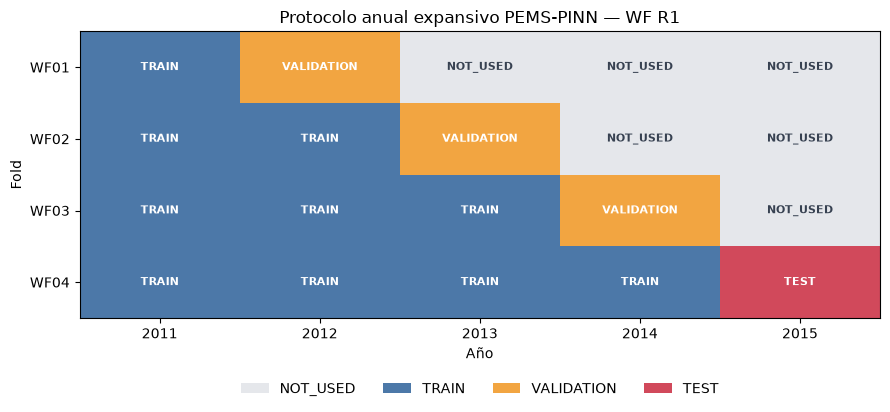

In [17]:
# [C-05.02] Cronología walk-forward

def plot_walk_forward_design(
    design: pd.DataFrame,
    output_path: Path,
) -> Path:
    """Dibuja la función de cada año en cada fold."""
    role_to_value = {
        "NOT_USED": 0,
        "TRAIN": 1,
        "VALIDATION": 2,
        "TEST": 3,
    }
    colors = ["#e5e7eb", "#4c78a8", "#f2a541", "#d1495b"]
    values = np.array(
        [
            [role_to_value[role] for role in row]
            for row in design[[str(year) for year in ALL_YEARS]].to_numpy()
        ]
    )

    figure, axis = plt.subplots(figsize=(9, 4.3))
    axis.imshow(
        values,
        aspect="auto",
        cmap=plt.matplotlib.colors.ListedColormap(colors),
        vmin=0,
        vmax=3,
    )
    axis.set_xticks(range(len(ALL_YEARS)), labels=ALL_YEARS)
    axis.set_yticks(range(len(design)), labels=design["fold"])
    axis.set_xlabel("Año")
    axis.set_ylabel("Fold")
    axis.set_title("Protocolo anual expansivo PEMS-PINN — WF R1")

    for row_index in range(len(design)):
        for column_index, year in enumerate(ALL_YEARS):
            role = design.loc[row_index, str(year)]
            text_color = "white" if role != "NOT_USED" else "#374151"
            axis.text(
                column_index,
                row_index,
                role,
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
                fontweight="bold",
            )

    legend = [
        Patch(facecolor=colors[value], label=role)
        for role, value in role_to_value.items()
    ]
    axis.legend(
        handles=legend,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=4,
        frameon=False,
    )
    figure.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(figure)
    return output_path


WF_DESIGN_FIGURE_PATH = plot_walk_forward_design(
    WF_DESIGN_MATRIX,
    PATHS["figures"] / "FIG-01_WF_ANNUAL_DESIGN.png",
)


### C-05.03 / OUT-05 — Lectura de la matriz

**Objetivo:** mostrar la tabla que respalda la figura.  
**Entradas:** `WF_DESIGN_MATRIX`.  
**Salidas:** tabla visible.  
**Control:** no se calculan métricas predictivas.


In [18]:
# [C-05.03] Lectura de la matriz

display(WF_DESIGN_MATRIX)
print(f"Figura guardada en: {WF_DESIGN_FIGURE_PATH}")


,fold,2011,2012,2013,2014,2015
0,WF01,TRAIN,VALIDATION,NOT_USED,NOT_USED,NOT_USED
1,WF02,TRAIN,TRAIN,VALIDATION,NOT_USED,NOT_USED
2,WF03,TRAIN,TRAIN,TRAIN,VALIDATION,NOT_USED
3,WF04,TRAIN,TRAIN,TRAIN,TRAIN,TEST


Figura guardada en: C:\ChatGPT-Work\Walk_Forward R8\models\wf\work_pinn_wf_protocol\figures\FIG-01_WF_ANNUAL_DESIGN.png


## SEC-06 — Comprobaciones integrales de aceptación

Antes de congelar artefactos se vuelve a verificar identidad de datos DEV,
barrera de 2015, integridad de filas, folds y contratos.

### C-06.01 / CHK-07 — Gates finales

**Objetivo:** consolidar todos los controles críticos en una tabla auditable.  
**Entradas:** datos, hashes, asignación, folds y contratos.  
**Salidas:** `INTEGRITY_CHECKS` y hashes posteriores.  
**Acción ante fallo:** detener sin crear manifiestos FROZEN.


In [19]:
# [C-06.01] Gates finales

def run_integrity_checks(
    root: Path,
    data_paths: dict[int, Path],
    data: pd.DataFrame,
    assignment: pd.DataFrame,
) -> tuple[dict[str, bool], pd.DataFrame, dict]:
    """Ejecuta los gates científicos y de reproducibilidad."""
    data_hashes_after = collect_development_hashes(root, data_paths)
    holdout_path = data_paths[FINAL_TEST_YEAR]
    holdout_stat_after = {
        "path": str(holdout_path.relative_to(root)),
        "bytes": holdout_path.stat().st_size,
        "mtime_ns": holdout_path.stat().st_mtime_ns,
        "sha256": "NOT_COMPUTED_BY_PROTOCOL",
    }
    observed_rows = (
        data.groupby("year").size().astype(int).to_dict()
    )

    checks = {
        "canonical_files_exist": all(
            path.is_file() for path in data_paths.values()
        ),
        "all_headers_exact": all(
            header == EXPECTED_COLUMNS
            for header in DATA_HEADERS.values()
        ),
        "development_rows_exact": len(data) == EXPECTED_DEVELOPMENT_ROWS,
        "annual_development_rows_exact": observed_rows
        == {
            year: EXPECTED_ROWS_BY_YEAR[year]
            for year in DEVELOPMENT_YEARS
        },
        "targets_absent_from_memory": not (
            set(PROTECTED_TARGETS) & set(data.columns)
        ),
        "2015_absent_from_memory": FINAL_TEST_YEAR
        not in data["year"].unique(),
        "unique_global_row_id": assignment["global_row_id"].is_unique,
        "unique_global_position": assignment["global_position"].is_unique,
        "complete_assignment_coverage": len(assignment) == len(data),
        "zero_materialized_target_reads": (
            TARGET_ACCESS_AUDIT["materialized_target_value_reads"] == 0
        ),
        "2015_header_only": (
            HOLDOUT_ACCESS_AUDIT["header_read"]
            and not HOLDOUT_ACCESS_AUDIT["feature_values_materialized"]
            and not HOLDOUT_ACCESS_AUDIT["target_values_materialized"]
        ),
        "2015_not_hashed": not HOLDOUT_ACCESS_AUDIT[
            "content_sha256_computed"
        ],
        "2015_stat_unchanged": HOLDOUT_STAT_BEFORE == holdout_stat_after,
        "development_files_unchanged": DATA_HASHES_BEFORE.equals(
            data_hashes_after
        ),
        "fold_checks_pass": all(bool(value) for value in FOLD_CHECKS.values()),
        "contract_checks_pass": all(
            bool(value) for value in CONTRACT_CHECKS.values()
        ),
        "gap_frozen_at_zero": GAP_RECORDS == 0,
        "weighting_frozen_uniform": TEMPORAL_WEIGHTING == "uniform",
        "wf04_is_final_only": FOLD_SPECS[-1]["purpose"] == "FINAL_ONLY",
        "wf04_evaluates_2015": (
            FOLD_SPECS[-1]["evaluation_year"] == FINAL_TEST_YEAR
            and FOLD_SPECS[-1]["evaluation_role"] == "TEST"
        ),
    }
    return checks, data_hashes_after, holdout_stat_after


### C-06.02 / OUT-06 — Resultado de aceptación

**Objetivo:** ejecutar los gates y detener ante cualquier incumplimiento.  
**Entradas:** estado completo del protocolo.  
**Salidas:** tabla PASS/FAIL y auditoría posterior de hashes.  
**Control:** el congelamiento requiere 100 % de gates `PASS`.


In [20]:
# [C-06.02] Resultado de aceptación

print("Fase 3/4 · Gates de integridad")
(
    INTEGRITY_CHECKS,
    DATA_HASHES_AFTER,
    HOLDOUT_STAT_AFTER,
) = run_integrity_checks(
    PROJECT_ROOT,
    DATA_PATHS,
    DEVELOPMENT_X,
    ROW_ASSIGNMENT,
)
INTEGRITY_TABLE = pd.DataFrame(
    [
        {
            "check": name,
            "status": "PASS" if bool(passed) else "FAIL",
        }
        for name, passed in INTEGRITY_CHECKS.items()
    ]
)
display(INTEGRITY_TABLE)

failed_integrity_checks = INTEGRITY_TABLE.loc[
    INTEGRITY_TABLE["status"].eq("FAIL"), "check"
].tolist()
if failed_integrity_checks:
    raise AssertionError(
        f"Gates finales fallidos: {failed_integrity_checks}"
    )


Fase 3/4 · Gates de integridad


,check,status
0,canonical_files_exist,PASS
1,all_headers_exact,PASS
2,development_rows_exact,PASS
3,annual_development_rows_exact,PASS
4,targets_absent_from_memory,PASS
5,2015_absent_from_memory,PASS
6,unique_global_row_id,PASS
7,unique_global_position,PASS
8,complete_assignment_coverage,PASS
9,zero_materialized_target_reads,PASS


## SEC-07 — Persistencia, congelamiento y cierre

Los manifiestos de esta sección son la interfaz formal para los cuatro
notebooks consumidores. Se generan solo después de superar `SEC-06`.

### C-07.01 / ART-03–ART-06 — Construcción de manifiestos

**Objetivo:** preparar manifiestos de protocolo, folds, consumidores y campaña.  
**Entradas:** decisiones, asignaciones, hashes y gates aprobados.  
**Salidas:** payloads con estado `FROZEN`.  
**Control:** cada manifiesto registra versión, alcance y protección de TEST.


In [21]:
# [C-07.01] Construcción de manifiestos

def build_manifests(
    assignment_hash: str,
    fold_summary_hash: str,
    design_matrix_hash: str,
    figure_hash: str,
) -> dict[str, dict]:
    """Construye los cuatro contratos FROZEN consumidos aguas abajo."""
    folds = []
    for spec in FOLD_SPECS:
        summary = FOLD_SUMMARY.loc[
            FOLD_SUMMARY["fold"].eq(spec["fold"])
        ].iloc[0]
        folds.append(
            {
                **spec,
                "gap_records": GAP_RECORDS,
                "temporal_weighting": TEMPORAL_WEIGHTING,
                "n_train": int(summary["N_train"]),
                "n_evaluation_expected": int(
                    summary["N_evaluation_expected"]
                ),
                "evaluation_values_materialized_by_protocol": bool(
                    summary["evaluation_values_materialized"]
                ),
            }
        )

    protocol_manifest = {
        "protocol_version": PROTOCOL_VERSION,
        "status": "FROZEN",
        "generated_at_utc": PROTOCOL_FREEZE_UTC,
        "scope": (
            "Annual expanding walk-forward shared by NOX and CO; "
            "2015 reserved for FINAL."
        ),
        "features": FEATURES,
        "protected_targets": PROTECTED_TARGETS,
        "development_years": DEVELOPMENT_YEARS,
        "final_test_year": FINAL_TEST_YEAR,
        "expected_rows_by_year": EXPECTED_ROWS_BY_YEAR,
        "expected_development_rows": EXPECTED_DEVELOPMENT_ROWS,
        "fixed_parameters": {
            "gap_records": GAP_RECORDS,
            "temporal_weighting": TEMPORAL_WEIGHTING,
        },
        "test_protection": {
            "x_2015_materialized": False,
            "y_2015_materialized": False,
            "metrics_2015_computed": False,
            "sha256_2015_computed": False,
            "authorized_stage": "WF_FINAL_AFTER_FROZEN_HANDOFF",
        },
        "development_data_hashes": DATA_HASHES_AFTER[
            ["year", "path", "sha256"]
        ].to_dict(orient="records"),
        "reference_sources": REFERENCE_SOURCES,
        "row_assignment_sha256": assignment_hash,
        "fold_summary_sha256": fold_summary_hash,
        "design_matrix_sha256": design_matrix_hash,
        "figure_sha256": figure_hash,
    }
    folds_manifest = {
        "protocol_version": PROTOCOL_VERSION,
        "status": "FROZEN",
        "folds": folds,
        "development_folds": ["WF01", "WF02", "WF03"],
        "final_fold": "WF04",
        "annual_expanding": True,
        "row_assignment_scope": "2011_2014_ONLY",
        "row_assignment_sha256": assignment_hash,
        "fold_summary_sha256": fold_summary_hash,
    }
    consumer_manifest = {
        "protocol_version": PROTOCOL_VERSION,
        "status": "FROZEN",
        "common_contract": COMMON_CONSUMER_CONTRACT,
        "target_contracts": TARGET_CONTRACTS,
        "optuna_owned_parameters": OPTUNA_OWNED_PARAMETERS,
        "optimization_exclusions": OPTIMIZATION_EXCLUSIONS,
    }
    campaign_manifest = {
        "protocol_version": PROTOCOL_VERSION,
        "status": "FROZEN",
        **CAMPAIGN_POLICY,
    }
    return {
        "WF_PROTOCOL_MANIFEST.json": protocol_manifest,
        "WF_FOLDS_MANIFEST.json": folds_manifest,
        "WF_CONSUMER_CONTRACT.json": consumer_manifest,
        "WF_CAMPAIGN_POLICY.json": campaign_manifest,
    }


### C-07.02 / ART-07 — Guía de ejecución e informe técnico

**Objetivo:** documentar ejecución, alcance y handoff para revisión externa.  
**Entradas:** folds y contratos aprobados.  
**Salidas:** README e informe técnico en `reports/`.  
**Control:** la documentación no puede afirmar evaluación de 2015.


In [22]:
# [C-07.02] Guía de ejecución e informe técnico

def write_protocol_reports(paths: dict[str, Path]) -> None:
    """Escribe documentación compacta para ejecución y revisión."""
    readme = """# Ejecución en Google Colab — protocolo WF R1

1. Conserve `gt_2011.csv` a `gt_2015.csv` en `data/raw/`.
2. Abra `notebooks/00_PEMS_PINN_WF_PROTOCOL - R1.ipynb`.
3. Ejecute **Runtime → Run all** en CPU.
4. Revise que todos los gates de SEC-06 estén en `PASS`.
5. Consuma los manifiestos de `models/wf/work_pinn_wf_protocol/` desde los
   notebooks OPT y FINAL.

El protocolo materializa X solo para 2011–2014. De 2015 lee únicamente el
encabezado; no construye X, y, hashes de contenido ni métricas de ese año.
"""
    report = f"""# Informe técnico — protocolo walk-forward R1

## Resultado

El diseño quedó **FROZEN** con {EXPECTED_DEVELOPMENT_ROWS:,} filas de desarrollo,
tres folds de selección y un fold FINAL protegido:

- WF01: 2011 → 2012;
- WF02: 2011–2012 → 2013;
- WF03: 2011–2013 → 2014;
- WF04: 2011–2014 → 2015.

`gap_records = 0` y `temporal_weighting = uniform` son decisiones fijas. NOx
utiliza `TIT_INC`; CO utiliza `CDP_NEG`. `lambda_phys` permanece dentro del
espacio de optimización de cada consumidor.

## Protección de TEST

El protocolo no materializó variables ni objetivos de 2015, no calculó su hash
de contenido y no produjo métricas de TEST. El año solo puede abrirse en un
notebook WF FINAL después de recibir un handoff FROZEN del OPT correspondiente.

## Alcance

La evidencia es prospectiva anual dentro del dominio histórico 2011–2015. No
constituye certificación regulatoria, RATA, homologación PEMS/CEMS ni prueba de
causalidad física.
"""
    atomic_text(
        paths["reports"] / "README_EJECUCION_COLAB_WF_PROTOCOL.md",
        readme,
    )
    atomic_text(
        paths["reports"] / "INFORME_TECNICO_WF_PROTOCOL.md",
        report,
    )


### C-07.03 / ART-08 — Persistencia atómica y manifiesto general

**Objetivo:** guardar tablas, auditorías, manifiestos, reportes y hashes.  
**Entradas:** estado aprobado por `CHK-07`.  
**Salidas:** paquete reproducible del protocolo.  
**Control:** los hashes se calculan después de escribir cada artefacto.


In [23]:
# [C-07.03] Persistencia atómica y manifiesto general

def persist_protocol(
    output_dir: Path,
    paths: dict[str, Path],
) -> tuple[dict[str, dict], pd.DataFrame, dict]:
    """Persiste el contrato R1 y construye su índice de artefactos."""
    assignment_path = (
        paths["tables"] / "WF_DEVELOPMENT_ROW_ASSIGNMENT.csv"
    )
    fold_summary_path = paths["tables"] / "WF_FOLDS_SUMMARY.csv"
    design_matrix_path = (
        paths["tables"] / "WF_PROTOCOL_DESIGN_MATRIX.csv"
    )
    atomic_csv(assignment_path, ROW_ASSIGNMENT)
    atomic_csv(fold_summary_path, FOLD_SUMMARY)
    atomic_csv(design_matrix_path, WF_DESIGN_MATRIX)
    atomic_csv(
        paths["tables"] / "WF_FOLD_ROLE_COUNTS.csv",
        FOLD_ROLE_COUNTS,
    )
    atomic_csv(
        paths["audit"] / "WF_INTEGRITY_CHECKS.csv",
        INTEGRITY_TABLE,
    )
    atomic_csv(
        paths["audit"] / "WF_DATA_HASHES_AFTER.csv",
        DATA_HASHES_AFTER,
    )
    atomic_csv(
        paths["audit"] / "WF_REFERENCE_TRACEABILITY.csv",
        pd.DataFrame(REFERENCE_SOURCES),
    )

    manifests = build_manifests(
        assignment_hash=sha256_file(assignment_path),
        fold_summary_hash=sha256_file(fold_summary_path),
        design_matrix_hash=sha256_file(design_matrix_path),
        figure_hash=sha256_file(WF_DESIGN_FIGURE_PATH),
    )
    for filename, payload in manifests.items():
        atomic_json(paths["manifests"] / filename, payload)

    write_protocol_reports(paths)
    atomic_json(
        paths["audit"] / "LAST_RUN_RUNTIME.json",
        {
            "last_run_finished_at_utc": utc_now(),
            "elapsed_seconds": time.perf_counter() - RUN_STARTED,
        },
    )

    artifact_paths = [
        paths["audit"] / "WF_ENVIRONMENT_MANIFEST.json",
        paths["audit"] / "WF_DATA_HASHES_BEFORE.csv",
        paths["audit"] / "WF_DATA_HASHES_AFTER.csv",
        paths["audit"] / "WF_DATA_PREFLIGHT.csv",
        paths["audit"] / "WF_TARGET_ACCESS_AUDIT.json",
        paths["audit"] / "WF_HOLDOUT_ACCESS_AUDIT.json",
        paths["audit"] / "WF_INTEGRITY_CHECKS.csv",
        paths["audit"] / "WF_REFERENCE_TRACEABILITY.csv",
        paths["tables"] / "WF_DEVELOPMENT_ROW_ASSIGNMENT.csv",
        paths["tables"] / "WF_FOLDS_SUMMARY.csv",
        paths["tables"] / "WF_FOLD_ROLE_COUNTS.csv",
        paths["tables"] / "WF_PROTOCOL_DESIGN_MATRIX.csv",
        paths["figures"] / "FIG-01_WF_ANNUAL_DESIGN.png",
        paths["manifests"] / "WF_PROTOCOL_MANIFEST.json",
        paths["manifests"] / "WF_FOLDS_MANIFEST.json",
        paths["manifests"] / "WF_CONSUMER_CONTRACT.json",
        paths["manifests"] / "WF_CAMPAIGN_POLICY.json",
        paths["reports"] / "README_EJECUCION_COLAB_WF_PROTOCOL.md",
        paths["reports"] / "INFORME_TECNICO_WF_PROTOCOL.md",
    ]
    missing_artifacts = [path for path in artifact_paths if not path.is_file()]
    if missing_artifacts:
        raise FileNotFoundError(
            f"Artefactos obligatorios ausentes: {missing_artifacts}"
        )

    artifact_hashes = pd.DataFrame(
        [
            {
                "path": str(path.relative_to(output_dir)),
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
            for path in artifact_paths
        ]
    ).sort_values("path").reset_index(drop=True)
    atomic_csv(
        paths["audit"] / "HASHES_ARTEFACTOS_WF_PROTOCOL.csv",
        artifact_hashes,
    )
    general_manifest = {
        "protocol_version": PROTOCOL_VERSION,
        "status": "FROZEN",
        "generated_at_utc": PROTOCOL_FREEZE_UTC,
        "artifact_count": len(artifact_hashes),
        "artifacts": artifact_hashes.to_dict(orient="records"),
        "test_2015_opened": False,
        "test_2015_metrics_computed": False,
    }
    atomic_json(
        paths["manifests"] / "MANIFIESTO_ARTEFACTOS_WF_PROTOCOL.json",
        general_manifest,
    )
    return manifests, artifact_hashes, general_manifest


### C-07.04 / OUT-07 — Congelamiento y handoff

**Objetivo:** persistir el paquete y mostrar el estado final en una sola salida.  
**Entradas:** gates aprobados y artefactos construidos.  
**Salidas:** manifiestos FROZEN, hashes y resumen ejecutivo.  
**Control:** `TEST_2015_OPENED` y `TEST_2015_METRICS_COMPUTED` deben ser `FALSE`.


In [24]:
# [C-07.04] Congelamiento y handoff

print("Fase 4/4 · Persistencia y congelamiento")
MANIFESTS, ARTIFACT_HASHES, GENERAL_MANIFEST = persist_protocol(
    OUTPUT_DIR,
    PATHS,
)
RUN_ELAPSED_SECONDS = time.perf_counter() - RUN_STARTED

final_summary = pd.DataFrame(
    [
        {
            "estado": GENERAL_MANIFEST["status"],
            "filas DEV": len(ROW_ASSIGNMENT),
            "folds de desarrollo": 3,
            "fold FINAL protegido": "WF04",
            "gap": GAP_RECORDS,
            "ponderación": TEMPORAL_WEIGHTING,
            "física NOx": TARGET_CONTRACTS["NOX"]["physics_mode"],
            "física CO": TARGET_CONTRACTS["CO"]["physics_mode"],
            "TEST_2015_OPENED": False,
            "TEST_2015_METRICS_COMPUTED": False,
            "artefactos indexados": GENERAL_MANIFEST["artifact_count"],
            "duración (s)": RUN_ELAPSED_SECONDS,
            "ruta": str(OUTPUT_DIR),
        }
    ]
)
display(final_summary.T.rename(columns={0: "resultado"}))
print("HANDOFF: protocolo WF R1 FROZEN y listo para consumidores OPT/FINAL")


Fase 4/4 · Persistencia y congelamiento


,resultado
estado,FROZEN
filas DEV,29349
folds de desarrollo,3
fold FINAL protegido,WF04
gap,0
ponderación,uniform
física NOx,TIT_INC
física CO,CDP_NEG
TEST_2015_OPENED,False
TEST_2015_METRICS_COMPUTED,False


HANDOFF: protocolo WF R1 FROZEN y listo para consumidores OPT/FINAL
